# Scenario I — ViT-Pretrained
## Melanoma Classification via Bayesian Optimisation with Tree-structured Parzen Estimator (TPE)

Notebook ini melatih **ViT-Small/16 Pretrained** untuk klasifikasi melanoma menggunakan dua tahap:

1. **TPE Hyperparameter Search** — Optuna dengan `TPESampler` (multivariate) mencari konfigurasi terbaik dari 15 trial, masing-masing dilatih 8 epoch pada validation split. Budget lebih kecil dari CNN karena ViT lebih berat secara komputasi (~22M params).
2. **Final Training** — Model dilatih 30 epoch dengan *progressive unfreezing* bertahap (ui_vit → last_2_blocks → full, di mana ui_vit ∈ {last_block, last_2_blocks} dari hasil TPE) dan *Layer-wise LR Decay* (LLRD).

Hasil akhir dievaluasi pada DS1 (Kaggle test set) dan DS2 (Mendeley cross-dataset), lalu disimpan sebagai probabilitas `.npy` untuk digunakan di Scenario II (ensemble).


## 0. Instalasi

Cell berikut berisi skrip instalasi PyTorch versi CUDA 11.8 yang dinonaktifkan (di-comment) karena environment Kaggle biasanya sudah menyertakan versi yang kompatibel. Aktifkan hanya jika versi PyTorch yang terinstal tidak sesuai dengan GPU yang digunakan, lalu **restart kernel** sebelum melanjutkan.


In [1]:
# import subprocess, sys

# subprocess.check_call([
#     sys.executable, '-m', 'pip', 'install',
#     'torch==2.5.1+cu118',
#     'torchvision==0.20.1+cu118',
#     '--index-url', 'https://download.pytorch.org/whl/cu118',
#     '-q',
#     '--root-user-action=ignore',
#     '--disable-pip-version-check'
# ])

# print('Installation complete')
# print('IMPORTANT: restart the kernel before proceeding')


## 1. Import, Seed & Device

Mengimpor seluruh library yang dibutuhkan, lalu mengunci semua sumber randomness (`random`, `numpy`, `torch`) ke `SEED = 42` agar eksperimen dapat direproduksi. Deteksi device dilakukan otomatis — GPU digunakan jika tersedia, beserta Automatic Mixed Precision (AMP) untuk efisiensi memori.


In [2]:
import os, json, time, warnings, random, math
from pathlib import Path
from copy import deepcopy
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.cuda.amp import GradScaler, autocast
from torch.utils.data import DataLoader, WeightedRandomSampler, Subset
from torchvision import transforms
from torchvision.datasets import ImageFolder
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, roc_curve
)
import timm
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

DEVICE  = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
USE_AMP = torch.cuda.is_available()

print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    print(f'VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB')
print(f'USE_AMP : {USE_AMP}')
print(f'torch   : {torch.__version__}')
print(f'timm    : {timm.__version__}')
print(f'optuna  : {optuna.__version__}')


Device  : cuda
GPU     : Tesla P100-PCIE-16GB
VRAM    : 17.1 GB
USE_AMP : True
torch   : 2.5.1+cu118
timm    : 1.0.26
optuna  : 4.8.0


## 2. Konfigurasi

Mendefinisikan seluruh konstanta eksperimen dalam satu tempat:

- **Path dataset**: DS1 (Kaggle — bhaveshmittal) dan DS2 (Kaggle — hasnainjaved) beserta direktori output dan checkpoint.
- **Hyperparameter pelatihan**: jumlah kelas, jumlah worker DataLoader, gradient clipping, dan jumlah langkah TTA.
- **Konfigurasi TPE untuk ViT**: 15 trial (`N_TRIALS`) × 8 epoch (`TPE_EPOCHS`) — lebih kecil dari CNN karena ViT jauh lebih berat. Warmup 8 trial random sebelum TPE aktif.
- **Jadwal unfreezing** (`CNN_UNFREEZE`): referensi untuk arsitektur CNN. ViT menggunakan jadwal sendiri di cell 17. Final Training dengan threshold yang lebih agresif.
- **Baseline referensi** (`PAPER_REF`): metrik dari paper acuan untuk perbandingan hasil akhir.


In [3]:
DS1_BASE  = Path('/kaggle/input/datasets/bhaveshmittal/melanoma-cancer-dataset')
DS1_TRAIN = DS1_BASE / 'train'
DS1_TEST  = DS1_BASE / 'test'
DS2_BASE  = Path('/kaggle/input/datasets/hasnainjaved/melanoma-skin-cancer-dataset-of-10000-images')
DS2_TEST  = DS2_BASE / 'melanoma_cancer_dataset' / 'test'
OUTPUT_DIR = Path('/kaggle/working/full_pipeline_results')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
CKPT_DIR   = OUTPUT_DIR / 'checkpoints'
CKPT_DIR.mkdir(exist_ok=True)

NUM_CLASSES  = 2
NUM_WORKERS  = 4
GRAD_CLIP    = 1.0
TTA_STEPS    = 10

N_TRIALS        = 15
TPE_EPOCHS      = 8
TPE_ES_PAT      = 3
TPE_WARMUP_TR   = 8
FINAL_EPOCHS    = 35
VIT_FINAL_EP    = 30
ENS_TRIALS      = 100

VIT_MODEL_NAME  = 'vit_small_patch16_224'
VIT_IMG_SIZE    = 224

CNN_UNFREEZE = {
    1  : 'frozen',
    5  : 'last_block',
    10 : 'last_2_blocks',
    18 : 'full',
}

ARCH_CONFIGS = {
    'densenet121': {
        'label'            : 'DenseNet-121',
        'img_size'         : 224,
        'unfreeze_schedule': CNN_UNFREEZE,
    },
    'inception_v3': {
        'label'            : 'InceptionV3',
        'img_size'         : 299,
        'unfreeze_schedule': CNN_UNFREEZE,
    },
    'xception': {
        'label'            : 'Xception',
        'img_size'         : 299,
        'unfreeze_schedule': CNN_UNFREEZE,
    },
}

MODEL_LABELS = {
    'densenet121'  : 'DenseNet-121',
    'inception_v3' : 'InceptionV3',
    'xception'     : 'Xception',
    'vit_scratch'  : 'ViT-Pretrained',
}

PAPER_REF = {
    'DenseNet-121'    : {'accuracy':0.9450, 'precision':0.9390,
                          'recall':0.9504,   'f1':0.9447},
    'InceptionV3'     : {'accuracy':0.9120, 'precision':0.9320,
                          'recall':0.8962,   'f1':0.9137},
    'Xception'        : {'accuracy':0.9380, 'precision':0.9300,
                          'recall':0.9451,   'f1':0.9375},
    'ViT-Pretrained'  : {'accuracy':0.8825, 'precision':0.9050,
                          'recall':0.8660,   'f1':0.8850},
    'Ensemble'        : {'accuracy':0.9525, 'precision':0.9420,
                          'recall':0.9622,   'f1':0.9520},
}

print('Configuration loaded successfully')
print(f'  N_TRIALS     = {N_TRIALS}')
print(f'  TPE_EPOCHS   = {TPE_EPOCHS}')
print(f'  TPE_ES_PAT   = {TPE_ES_PAT}')
print(f'  FINAL_EPOCHS = {FINAL_EPOCHS}')
print(f'  VIT_FINAL_EP = {VIT_FINAL_EP}')
print(f'  ENS_TRIALS   = {ENS_TRIALS}')
print(f'  ViT model    = {VIT_MODEL_NAME}')
print(f'  Unfreeze full at epoch {max(CNN_UNFREEZE.keys())} of {FINAL_EPOCHS}'
      f'  → {FINAL_EPOCHS - max(CNN_UNFREEZE.keys())}')
print()
print('Baseline Paper Reference:')
print(f'{"Model":<18} {"Accuracy":>10} {"Recall":>8} {"F1":>8}')
print('-' * 46)
for model, vals in PAPER_REF.items():
    print(f'{model:<18} {vals["accuracy"]:>10.2%} '
          f'{vals["recall"]:>8.2%} {vals["f1"]:>8.2%}')

Configuration loaded successfully
  N_TRIALS     = 15
  TPE_EPOCHS   = 8
  TPE_ES_PAT   = 3
  FINAL_EPOCHS = 35
  VIT_FINAL_EP = 30
  ENS_TRIALS   = 100
  ViT model    = vit_small_patch16_224
  Unfreeze full at epoch 18 of 35  → 17

Baseline Paper Reference:
Model                Accuracy   Recall       F1
----------------------------------------------
DenseNet-121           94.50%   95.04%   94.47%
InceptionV3            91.20%   89.62%   91.37%
Xception               93.80%   94.51%   93.75%
ViT-Pretrained         88.25%   86.60%   88.50%
Ensemble               95.25%   96.22%   95.20%


## 3. Data Pipeline

Mendefinisikan dua fungsi utama:

**`get_transforms(split, img_size)`** — augmentasi berbeda per mode:
- `train`: augmentasi penuh (crop, flip, rotasi, color jitter, affine, grayscale, random erasing) untuk regularisasi.
- `tta` *(Test-Time Augmentation)*: augmentasi ringan yang diaplikasikan berulang saat inferensi untuk meningkatkan stabilitas prediksi.
- `val/test`: hanya resize dan normalisasi ImageNet — tanpa augmentasi.

**`build_dataloaders(batch_size, img_size)`** — membangun DataLoader untuk train, validation, dan test:
- Dataset dibagi stratified (85% train / 15% val) agar distribusi kelas tetap proporsional.
- `WeightedRandomSampler` digunakan dengan bobot invers-sqrt frekuensi kelas. Ukuran sampler digandakan (`len(sw) × 2`) agar kelas minoritas mendapat representasi yang cukup di setiap epoch.


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

def get_transforms(split, img_size):
    if split == 'train':
        return transforms.Compose([
            transforms.Resize((img_size + 24, img_size + 24)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.RandomRotation(25),
            transforms.ColorJitter(0.15, 0.15, 0.15, 0.08),
            transforms.RandomAffine(
                0, translate=(0.1, 0.1),
                scale=(0.85, 1.15), shear=5),
            transforms.RandomGrayscale(p=0.05),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
            transforms.RandomErasing(p=0.15, scale=(0.02, 0.1)),
        ])
    elif split == 'tta':
        return transforms.Compose([
            transforms.Resize((img_size + 16, img_size + 16)),
            transforms.RandomCrop(img_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomVerticalFlip(),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])
    else:
        return transforms.Compose([
            transforms.Resize((img_size, img_size)),
            transforms.ToTensor(),
            transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
        ])

def build_dataloaders(batch_size, img_size, val_split=0.15):
    full_ds = ImageFolder(
        DS1_TRAIN, transform=get_transforms('train', img_size))
    targets = [s[1] for s in full_ds.samples]
    cc      = [targets.count(i) for i in range(NUM_CLASSES)]

    tr_idx, vl_idx = train_test_split(
        range(len(full_ds)), test_size=val_split,
        stratify=targets, random_state=SEED)

    tr_ds   = Subset(full_ds, tr_idx)
    vl_base = ImageFolder(
        DS1_TRAIN, transform=get_transforms('val', img_size))
    vl_ds   = Subset(vl_base, vl_idx)

    tr_tgt   = np.array(targets)[tr_idx]
    class_cnt = np.bincount(tr_tgt)
    class_w  = 1.0 / np.sqrt(class_cnt.astype(float))
    class_w  = class_w / class_w.sum() * len(class_cnt)
    sw       = class_w[tr_tgt]
    smp      = WeightedRandomSampler(
        torch.DoubleTensor(sw), len(sw) * 2, replacement=True)

    tr_ld = DataLoader(
        tr_ds, batch_size, sampler=smp,
        num_workers=NUM_WORKERS, pin_memory=True)
    vl_ld = DataLoader(
        vl_ds, batch_size, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True)
    te_ds = ImageFolder(
        DS1_TEST, transform=get_transforms('test', img_size))
    te_ld = DataLoader(
        te_ds, 32, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=True)

    return tr_ld, vl_ld, te_ld, full_ds.classes, cc

_, _, _, CLASS_NAMES, _ = build_dataloaders(32, 224)
print(f'Class names : {CLASS_NAMES}')

Class names : ['Benign', 'Malignant']


## 4. Model Factory

Mendefinisikan semua komponen yang dibutuhkan untuk membangun dan mengonfigurasi model:

- **`CNNWithHead`**: wrapper di atas backbone timm yang mengganti head default dengan head dua-lapisan (`Linear → BN → GELU → Dropout → Linear`), memberikan kapasitas adaptasi lebih besar.
- **`build_cnn`**: membuat CNN pretrained dengan `num_classes=0` (timm mengembalikan fitur mentah tanpa head klasifikasi) lalu menyambungkan `CNNWithHead`.
- **`apply_freeze` / `progressive_unfreeze`**: mengontrol parameter mana yang trainable sesuai strategi (`frozen`, `last_block`, `last_2_blocks`, `full`). Parameter afine normalisasi (LayerNorm: weight & bias) sengaja tidak dibekukan di semua fase karena membantu kalibrasi ulang distribusi aktivasi (*partial fine-tuning*, Li et al. 2017). Untuk ViT, ini berarti bobot attention projection dibekukan tapi LayerNorm-nya tetap trainable.
- **`build_optimizer`**: membangun Adam/AdamW/Adamax. Jika `layer_decay` diberikan, menerapkan *Layer-wise LR Decay* (LLRD) khusus untuk ViT — setiap blok menerima LR yang semakin kecil mendekati patch embedding, mencegah degradasi representasi visual yang sudah dipelajari dari ImageNet.
- **`FocalLoss`**: loss alternatif yang memberi bobot lebih besar pada sampel sulit, efektif untuk dataset tidak seimbang. Menggunakan pembobotan *Effective Number of Samples* (formula `(1 - β^n) / (1 - β)`) yang lebih superior dari inverse-frequency murni.
- **`build_vit_pretrained`**: membangun ViT-Small/16 pretrained dengan head dua-lapisan khusus.


In [5]:

class CNNWithHead(nn.Module):
    """CNN wrapper with custom head: GAP → BN → GELU → Dropout → Linear.
    Provides greater adaptation capacity than the default timm head.
    """
    def __init__(self, backbone, n_features, dropout, num_classes):
        super().__init__()
        self.backbone = backbone
        self.head = nn.Sequential(
            nn.Linear(n_features, 512),
            nn.BatchNorm1d(512),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(512, num_classes),
        )
        self._init_head()

    def _init_head(self):
        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.trunc_normal_(m.weight, std=0.02)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)
            elif isinstance(m, nn.BatchNorm1d):
                nn.init.ones_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x):
        return self.head(self.backbone(x))

def build_cnn(arch_name, dropout):
    """Build a pretrained CNN with a 512-dim custom classification head."""
    backbone   = timm.create_model(
        arch_name, pretrained=True,
        drop_rate=dropout, num_classes=0)
    n_features = backbone.num_features
    return CNNWithHead(backbone, n_features, dropout, NUM_CLASSES)

def apply_freeze(model, strategy):
    if isinstance(model, CNNWithHead):
        params = list(model.backbone.named_parameters())
        for p in model.head.parameters():
            p.requires_grad_(True)
    else:
        params = list(model.named_parameters())

    total = len(params)
    for _, p in params:
        p.requires_grad_(False)

    for name, p in params:
        if any(k in name for k in ('head', 'classifier', 'fc', 'last_linear', 'norm')):
            p.requires_grad_(True)

    if strategy == 'last_block':
        for i, (_, p) in enumerate(params):
            if i >= int(total * 0.85):
                p.requires_grad_(True)
    elif strategy == 'last_2_blocks':
        for i, (_, p) in enumerate(params):
            if i >= int(total * 0.70):
                p.requires_grad_(True)
    elif strategy == 'full':
        for _, p in params:
            p.requires_grad_(True)
        if isinstance(model, CNNWithHead):
            for p in model.head.parameters():
                p.requires_grad_(True)

    tr  = sum(p.numel() for p in model.parameters() if p.requires_grad)
    tot = sum(p.numel() for p in model.parameters())
    return model, tr, tot

def progressive_unfreeze(model, epoch, schedule):
    strategy = 'frozen'
    for ep, strat in sorted(schedule.items()):
        if epoch >= ep:
            strategy = strat
    model, tr, _ = apply_freeze(model, strategy)
    return model, strategy, tr

def build_optimizer(model, opt_name, lr, wd, layer_decay=None):
    """Build optimizer. If layer_decay is provided, applies LLRD for ViT."""
    if layer_decay is not None and hasattr(model, 'blocks'):
        depth  = len(model.blocks)
        groups = []
        groups.append({'params': list(model.head.parameters()), 'lr': lr})
        groups.append({'params': list(model.norm.parameters()),  'lr': lr})
        for i, block in enumerate(reversed(model.blocks)):
            decay_factor = layer_decay ** (i + 1)
            groups.append({'params': list(block.parameters()), 'lr': lr * decay_factor})
        groups.append({'params': [model.patch_embed.proj.weight,
                                   model.patch_embed.proj.bias,
                                   model.cls_token, model.pos_embed],
                       'lr': lr * (layer_decay ** (depth + 1))})
        return optim.AdamW(groups, weight_decay=wd)

    params = [p for p in model.parameters() if p.requires_grad]
    if opt_name == 'adam':
        return optim.Adam(params, lr=lr, weight_decay=wd)
    elif opt_name == 'adamax':
        return optim.Adamax(params, lr=lr, weight_decay=wd)
    return optim.AdamW(params, lr=lr, weight_decay=wd)

class FocalLoss(nn.Module):
    def __init__(self, gamma=2.0, alpha=None):
        super().__init__()
        self.gamma = gamma
        self.alpha = (torch.tensor(alpha, dtype=torch.float32).to(DEVICE)
                      if alpha is not None else None)

    def forward(self, logits, targets):
        log_p  = F.log_softmax(logits, dim=1)
        ce     = F.nll_loss(log_p, targets, reduction='none')
        focal  = (1 - torch.exp(-ce)) ** self.gamma * ce
        if self.alpha is not None:
            focal = self.alpha[targets] * focal
        return focal.mean()

def build_criterion(use_focal, focal_gamma, label_smoothing, class_counts=None):
    """Select one: Focal Loss OR CrossEntropy+LabelSmoothing.
    Class weighting uses Effective Number of Samples.
    Superior to inverse-frequency weighting for moderate class imbalance.
    """
    alpha = None
    if class_counts:
        beta  = 0.9999
        eff   = [(1.0 - beta ** c) / (1.0 - beta) for c in class_counts]
        raw_a = [1.0 / e for e in eff]
        s     = sum(raw_a)
        alpha = [v / s * len(class_counts) for v in raw_a]

    if use_focal:
        return FocalLoss(gamma=focal_gamma, alpha=alpha)
    else:
        return nn.CrossEntropyLoss(
            label_smoothing=label_smoothing,
            weight=torch.tensor(alpha, dtype=torch.float32).to(DEVICE)
                  if alpha else None)

def build_vit_pretrained(dropout):
    """ViT-Small/16 pretrained on ImageNet — substantially better than training from scratch."""
    model = timm.create_model(
        VIT_MODEL_NAME,
        pretrained=True,
        drop_rate=dropout,
        attn_drop_rate=dropout * 0.5,
        drop_path_rate=0.1,
        num_classes=NUM_CLASSES,
    )
    in_features  = model.head.in_features
    model.head   = nn.Sequential(
        nn.Linear(in_features, 256),
        nn.GELU(),
        nn.Dropout(dropout),
        nn.Linear(256, NUM_CLASSES),
    )
    return model

_cnn = build_cnn('densenet121', 0.3).to(DEVICE)
_x   = torch.randn(2, 3, 224, 224).to(DEVICE)
_o   = _cnn(_x)
print(f'CNN output shape     : {tuple(_o.shape)}')
print(f'CNN total params     : {sum(p.numel() for p in _cnn.parameters())/1e6:.1f}M')

_vit = build_vit_pretrained(0.1).to(DEVICE)
_x2  = torch.randn(2, 3, 224, 224).to(DEVICE)
_o2  = _vit(_x2)
print(f'ViT output shape     : {tuple(_o2.shape)}')
print(f'ViT total params     : {sum(p.numel() for p in _vit.parameters())/1e6:.1f}M')
print(f'ViT model name       : {VIT_MODEL_NAME}  (pretrained=True)')

del _cnn, _vit, _x, _x2, _o, _o2
torch.cuda.empty_cache()
print('\nModel factory v2 ready')

model.safetensors:   0%|          | 0.00/32.3M [00:00<?, ?B/s]

CNN output shape     : (2, 2)
CNN total params     : 7.5M


model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

ViT output shape     : (2, 2)
ViT total params     : 21.8M
ViT model name       : vit_small_patch16_224  (pretrained=True)

Model factory v2 ready


## 5. Utilitas Pelatihan & Evaluasi

Mendefinisikan fungsi-fungsi inti yang dipanggil di setiap epoch:

- **`train_one_epoch`**: satu pass forward–backward dengan AMP (`autocast`), gradient clipping opsional, dan `GradScaler` untuk stabilitas numerik.
- **`evaluate`**: evaluasi pada loader tanpa gradient — mengembalikan loss, akurasi, AUC, serta array label dan probabilitas untuk analisis lanjut.
- **`get_probs`**: inferensi pada seluruh dataset dengan TTA opsional. Probabilitas dari setiap augmentasi dirata-rata untuk prediksi yang lebih stabil.
- **`compute_metrics`**: menghitung accuracy, precision, recall, F1, AUC, dan confusion matrix dari probabilitas dan label ground truth.


In [6]:
def train_one_epoch(model, loader, optimizer, criterion,
                    scaler, clip=None):
    model.train()
    loss_sum = correct = total = 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        optimizer.zero_grad(set_to_none=True)
        with autocast(enabled=USE_AMP):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        scaler.scale(loss).backward()
        if clip:
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), clip)
        scaler.step(optimizer)
        scaler.update()
        loss_sum += loss.item() * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader, criterion=None):
    model.eval()
    loss_sum = correct = total = 0
    all_p, all_l = [], []
    crit = criterion or nn.CrossEntropyLoss()
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        with autocast(enabled=USE_AMP):
            logits = model(imgs)
            loss   = crit(logits, labels)
        probs = torch.softmax(logits, 1)[:, 1]
        loss_sum += loss.item() * imgs.size(0)
        correct  += (logits.argmax(1) == labels).sum().item()
        total    += imgs.size(0)
        all_p.extend(probs.cpu().numpy())
        all_l.extend(labels.cpu().numpy())
    acc = correct / total
    try:
        auc = roc_auc_score(all_l, all_p)
    except Exception:
        auc = 0.0
    return (loss_sum / total, acc, auc,
            np.array(all_l), np.array(all_p))


@torch.no_grad()
def get_probs(model, ds_root, img_size, n_tta=1):
    model.eval()
    base_ds = ImageFolder(
        ds_root, transform=get_transforms('test', img_size))
    base_ld = DataLoader(
        base_ds, 32, shuffle=False, num_workers=NUM_WORKERS)
    labels_all = []
    probs_all  = np.zeros(len(base_ds), dtype=np.float32)
    idx = 0
    for imgs, labs in base_ld:
        with autocast(enabled=USE_AMP):
            p = torch.softmax(
                model(imgs.to(DEVICE)), 1)[:, 1].cpu().numpy()
        probs_all[idx:idx + len(p)] += p
        labels_all.extend(labs.numpy())
        idx += len(p)
    for _ in range(n_tta - 1):
        ds = ImageFolder(
            ds_root, transform=get_transforms('tta', img_size))
        ld = DataLoader(
            ds, 32, shuffle=False, num_workers=NUM_WORKERS)
        idx = 0
        for imgs, _ in ld:
            with autocast(enabled=USE_AMP):
                p = torch.softmax(
                    model(imgs.to(DEVICE)), 1)[:, 1].cpu().numpy()
            probs_all[idx:idx + len(p)] += p
            idx += len(p)
    return np.array(labels_all), probs_all / n_tta


def compute_metrics(labels, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    return {
        'accuracy'  : accuracy_score(labels, preds),
        'precision' : precision_score(labels, preds, zero_division=0),
        'recall'    : recall_score(labels, preds, zero_division=0),
        'f1'        : f1_score(labels, preds, zero_division=0),
        'auc'       : roc_auc_score(labels, probs),
        'conf_mat'  : confusion_matrix(labels, preds).tolist(),
        'threshold' : float(threshold),
    }


print('Utilities ready')
print(f'  USE_AMP = {USE_AMP}')


Utilities ready
  USE_AMP = True


## 6. TPE Objective & Search — ViT-Pretrained

Mendefinisikan dan menjalankan fungsi objektif Optuna untuk ViT:

**`make_vit_objective()`** — fungsi objektif khusus ViT dengan beberapa perbedaan dari CNN:
- Model dilatih 30 epoch dengan *progressive unfreezing* bertahap (ui_vit → last_2_blocks → full, di mana ui_vit ∈ {last_block, last_2_blocks} dari hasil TPE) dan *Layer-wise LR Decay* (LLRD).
- **Ruang pencarian**: LR `[5e-6, 5e-4]`
- **`layer_decay`** `[0.65, 0.90]`
- **`warmup_epochs`** `[3, 10]`
- **`unfreeze_init`** `['last_block', 'last_2_blocks']`: strategi awal unfreeze sebelum jadwal progresif aktif, juga dioptimasi oleh TPE.
- Setiap trial dilatih `TPE_EPOCHS` epoch dengan early stopping.

Setelah search selesai, hyperparameter terbaik disimpan ke `tpe_vit_pretrained.json` dan digunakan langsung di cell 17. Final Training.

In [7]:
all_models      = {}
all_probs_ds1   = {}
all_val_probs   = {}
all_metrics_ds1 = {}
all_val_labels  = None
ds1_labels      = None
tpe_best_params = {}

In [8]:

def make_vit_objective():
    n = {'i': 0}

    def objective(trial):
        n['i'] += 1

        lr          = trial.suggest_float('lr',           5e-6, 5e-4, log=True)
        bs          = trial.suggest_categorical('batch_size', [16, 32])
        dropout     = trial.suggest_float('dropout',      0.05, 0.25)
        wd          = trial.suggest_float('weight_decay', 1e-4, 1e-2, log=True)
        layer_decay = trial.suggest_float('layer_decay',  0.65, 0.90)
        ui          = trial.suggest_categorical('unfreeze_init',
                          ['last_block', 'last_2_blocks'])
        use_focal   = trial.suggest_categorical('use_focal', [True, False])
        fg          = trial.suggest_float('focal_gamma',     0.5, 1.5)
        ls          = trial.suggest_float('label_smoothing', 0.05, 0.15)
        warmup      = trial.suggest_int('warmup_epochs',    3, 10)

        print(f'  Trial {n["i"]:>2}/{N_TRIALS} '
              f'lr={lr:.1e} bs={bs} do={dropout:.2f} '
              f'ld={layer_decay:.2f} frz={ui} '
              f'focal={use_focal} warm={warmup}',
              end=' -> ')
        try:
            model = build_vit_pretrained(dropout).to(DEVICE)
            model, _, _ = apply_freeze(model, ui)

            tr_ld, vl_ld, _, _, cc = build_dataloaders(bs, VIT_IMG_SIZE)

            optimizer = build_optimizer(model, 'adamw', lr, wd,
                                        layer_decay=layer_decay)
            criterion = build_criterion(use_focal, fg, ls, cc)
            scaler    = GradScaler(enabled=USE_AMP)

            def lr_lambda(ep):
                if ep < warmup:
                    return (ep + 1) / warmup
                p = (ep - warmup) / (TPE_EPOCHS - warmup + 1e-8)
                return max(0.01, 0.5 * (1 + math.cos(math.pi * p)))

            scheduler = optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

            best_acc = 0.0
            no_impr  = 0
            for ep in range(TPE_EPOCHS):
                train_one_epoch(model, tr_ld, optimizer, criterion,
                                scaler, GRAD_CLIP)
                _, val_acc, _, _, _ = evaluate(model, vl_ld, criterion)
                scheduler.step()
                if val_acc > best_acc:
                    best_acc = val_acc
                    no_impr  = 0
                else:
                    no_impr += 1
                if no_impr >= TPE_ES_PAT:
                    break

            print(f'acc={best_acc:.4f}')
            del model, optimizer, scheduler, scaler, tr_ld, vl_ld
            torch.cuda.empty_cache()
            return best_acc
        except Exception as e:
            print(f'ERROR: {e}')
            torch.cuda.empty_cache()
            return 0.0
    return objective

print()
print('=' * 70)
print(f'  ViT-Pretrained ({VIT_MODEL_NAME}) | {VIT_IMG_SIZE}x{VIT_IMG_SIZE} | '
      f'TPE {N_TRIALS} trials × {TPE_EPOCHS} epoch')
print(f'  [multivariate TPE, LLRD, startup={TPE_WARMUP_TR}]')
print('=' * 70)

vit_sampler = optuna.samplers.TPESampler(
    seed=SEED,
    n_startup_trials=TPE_WARMUP_TR,
    multivariate=True,
    warn_independent_sampling=False,
)
vit_study = optuna.create_study(
    direction='maximize', sampler=vit_sampler,
    study_name='tpe_vit_pretrained')
vit_study.optimize(
    make_vit_objective(),
    n_trials=N_TRIALS, show_progress_bar=False)

vit_bp = dict(vit_study.best_trial.params)
vit_bp['optimizer_name'] = 'adamw'
tpe_best_params['vit_scratch'] = {**vit_bp, 'best_val_acc': vit_study.best_value}

print(f'\n  TPE ViT complete | best val acc: {vit_study.best_value:.4f}')
print(f'  Best params : {vit_bp}')

with open(OUTPUT_DIR / 'tpe_vit_pretrained.json', 'w') as f:
    json.dump(tpe_best_params['vit_scratch'], f, indent=2)


  ViT-Pretrained (vit_small_patch16_224) | 224x224 | TPE 15 trials × 8 epoch
  [multivariate TPE, LLRD, startup=8]
  Trial  1/15 lr=2.8e-05 bs=16 do=0.17 ld=0.69 frz=last_2_blocks focal=False warm=9 -> acc=0.8917
  Trial  2/15 lr=1.3e-05 bs=32 do=0.11 ld=0.76 frz=last_2_blocks focal=False warm=9 -> acc=0.8951
  Trial  3/15 lr=1.3e-05 bs=32 do=0.06 ld=0.69 frz=last_2_blocks focal=True warm=8 -> acc=0.8911
  Trial  4/15 lr=3.8e-05 bs=32 do=0.06 ld=0.71 frz=last_block focal=False warm=9 -> acc=0.9007
  Trial  5/15 lr=3.8e-04 bs=16 do=0.23 ld=0.70 frz=last_2_blocks focal=True warm=5 -> acc=0.8866
  Trial  6/15 lr=6.1e-05 bs=32 do=0.06 ld=0.84 frz=last_block focal=True warm=3 -> acc=0.9158
  Trial  7/15 lr=2.6e-05 bs=32 do=0.17 ld=0.67 frz=last_2_blocks focal=True warm=3 -> acc=0.8973
  Trial  8/15 lr=1.3e-04 bs=16 do=0.20 ld=0.78 frz=last_block focal=True warm=7 -> acc=0.9147
  Trial  9/15 lr=9.9e-05 bs=32 do=0.07 ld=0.88 frz=last_block focal=True warm=4 -> acc=0.9209
  Trial 10/15 lr=8.6

## 7. Final Training — ViT-Pretrained

Pelatihan penuh ViT-Small/16 selama `VIT_FINAL_EP` (30) epoch dengan hyperparameter terbaik dari TPE:

- **Progressive unfreezing** menggunakan jadwal khusus ViT (`VIT_UNFREEZE_SCHEDULE`): mulai dari strategi terbaik hasil TPE, lalu buka `last_2_blocks` di epoch 6, dan `full` di epoch 15 — memberikan 16 epoch full fine-tuning.
- Setiap perubahan strategi unfreeze memicu reset optimizer dan scheduler. LR di-reset ke nilai saat ini berdasarkan posisi dalam cosine decay agar transisi mulus.
- **LLRD** (`layer_decay`) diterapkan di setiap build optimizer: lapisan mendekati patch embedding menerima LR jauh lebih kecil untuk preservasi fitur visual ImageNet.
- Bobot terbaik (epoch dengan val accuracy tertinggi) di-checkpoint secara otomatis ke `vit_scratch_best.pth` dan di-load kembali setelah pelatihan selesai.


In [9]:
warmup      = vit_bp['warmup_epochs']
lr_vit      = vit_bp['lr']
bs_vit      = vit_bp['batch_size']
wd_vit      = vit_bp['weight_decay']
ld_vit      = vit_bp['layer_decay']
ui_vit      = vit_bp['unfreeze_init']
use_f_vit   = vit_bp['use_focal']
fg_vit      = vit_bp['focal_gamma']
ls_vit      = vit_bp['label_smoothing']
do_vit      = vit_bp['dropout']

print(f'Final Training ViT-Pretrained ({VIT_MODEL_NAME}) — {VIT_FINAL_EP} epochs')
print(f'Best params: {vit_bp}')

vit_model = build_vit_pretrained(do_vit).to(DEVICE)

VIT_UNFREEZE_SCHEDULE = {
    1  : ui_vit,
    6  : 'last_2_blocks',
    15 : 'full',
}

vit_model, _, _ = apply_freeze(vit_model, ui_vit)

tr_ld_v, vl_ld_v, _, _, cc_v = build_dataloaders(bs_vit, VIT_IMG_SIZE)
vit_crit   = build_criterion(use_f_vit, fg_vit, ls_vit, cc_v)
vit_scaler = GradScaler(enabled=USE_AMP)

def make_vit_opt(model, cur_lr):
    return build_optimizer(model, 'adamw', cur_lr, wd_vit, layer_decay=ld_vit)

vit_opt = make_vit_opt(vit_model, lr_vit)

def vit_lr_lambda(ep):
    if ep < warmup:
        return (ep + 1) / warmup
    p = (ep - warmup) / (VIT_FINAL_EP - warmup + 1e-8)
    return max(0.005, 0.5 * (1 + math.cos(math.pi * p)))

vit_sched     = optim.lr_scheduler.LambdaLR(vit_opt, vit_lr_lambda)
prev_strat_v  = None
vit_best_acc  = 0.0
vit_best_state= None
vit_best_ep   = 0
vit_vl_probs  = None
vit_vl_labels = None
vit_history   = {'train_loss':[], 'val_loss':[],
                 'train_acc':[], 'val_acc':[], 'val_auc':[]}

for epoch in range(1, VIT_FINAL_EP + 1):
    t0 = time.time()

    strat_v = ui_vit
    for ep_thr, s in sorted(VIT_UNFREEZE_SCHEDULE.items()):
        if epoch >= ep_thr:
            strat_v = s

    if strat_v != prev_strat_v:
        vit_model, _, n_tr_v = apply_freeze(vit_model, strat_v)
        cur_lr  = lr_vit * vit_lr_lambda(epoch - 1)
        vit_opt = make_vit_opt(vit_model, cur_lr)
        remaining = VIT_FINAL_EP - epoch + 1
        vit_sched = optim.lr_scheduler.CosineAnnealingLR(
            vit_opt, T_max=remaining, eta_min=cur_lr * 1e-3)
        print(f'  Epoch {epoch}: strategy -> {strat_v} '
              f'({n_tr_v:,} params trainable), lr={cur_lr:.2e}')
        prev_strat_v = strat_v

    tr_loss, tr_acc = train_one_epoch(
        vit_model, tr_ld_v, vit_opt, vit_crit, vit_scaler, GRAD_CLIP)
    vl_loss, vl_acc, vl_auc, vl_labels, vl_probs = evaluate(
        vit_model, vl_ld_v, vit_crit)
    vit_sched.step()

    vit_history['train_loss'].append(tr_loss)
    vit_history['val_loss'].append(vl_loss)
    vit_history['train_acc'].append(tr_acc)
    vit_history['val_acc'].append(vl_acc)
    vit_history['val_auc'].append(vl_auc)

    if vl_acc > vit_best_acc:
        vit_best_acc   = vl_acc
        vit_best_state = deepcopy(vit_model.state_dict())
        vit_best_ep    = epoch
        vit_vl_probs   = vl_probs
        vit_vl_labels  = vl_labels
        mark = ' <- best'
        torch.save({
            'state_dict'   : vit_best_state,
            'best_params'  : vit_bp,
            'best_epoch'   : vit_best_ep,
            'best_val_acc' : vit_best_acc,
            'history'      : vit_history,
            'model_name'   : VIT_MODEL_NAME,
        }, OUTPUT_DIR / 'vit_scratch_best.pth')
    else:
        mark = ''

    cur_lr = vit_opt.param_groups[0]['lr']
    print(f'  Ep {epoch:>2}/{VIT_FINAL_EP} '
          f'loss {tr_loss:.4f}/{vl_loss:.4f} '
          f'acc {tr_acc:.4f}/{vl_acc:.4f} '
          f'auc {vl_auc:.4f} '
          f'lr={cur_lr:.2e} '
          f'{time.time()-t0:.0f}s{mark}')

vit_model.load_state_dict(vit_best_state)
print(f'\n  Best weights from epoch {vit_best_ep} '
      f'(val acc={vit_best_acc:.4f})')

torch.save({
    'state_dict'   : vit_model.state_dict(),
    'best_params'  : vit_bp,
    'best_epoch'   : vit_best_ep,
    'best_val_acc' : vit_best_acc,
    'history'      : vit_history,
    'model_name'   : VIT_MODEL_NAME,
}, OUTPUT_DIR / 'vit_scratch_best.pth')

vit_labels_te, vit_probs_te = get_probs(
    vit_model, DS1_TEST, VIT_IMG_SIZE, TTA_STEPS)
vit_metrics = compute_metrics(vit_labels_te, vit_probs_te)

all_models['vit_scratch']      = vit_model
all_probs_ds1['vit_scratch']   = vit_probs_te
all_metrics_ds1['vit_scratch'] = vit_metrics
all_val_probs['vit_scratch']   = vit_vl_probs

paper_vit = PAPER_REF['ViT-Pretrained']
print(f'\n  ViT-Pretrained Results (TTA ×{TTA_STEPS}) vs. Baseline Paper:')
print(f'  {"Metric":<12} {"Ours":>8} {"Paper":>8} {"Delta":>9}')
print('  ' + '-' * 40)
for k in ['accuracy', 'precision', 'recall', 'f1']:
    d    = vit_metrics[k] - paper_vit[k]
    sign = 'OK' if d >= 0 else 'BELOW'
    print(f'  {k:<12} {vit_metrics[k]:>8.4f} '
          f'{paper_vit[k]:>8.4f} {d:>+9.4f}  {sign}')

torch.cuda.empty_cache()

Final Training ViT-Pretrained (vit_small_patch16_224) — 30 epochs
Best params: {'lr': 0.00036681669354887524, 'batch_size': 32, 'dropout': 0.11545929276873033, 'weight_decay': 0.001439921671170037, 'layer_decay': 0.8005280054963044, 'unfreeze_init': 'last_block', 'use_focal': True, 'focal_gamma': 1.2372815421259014, 'label_smoothing': 0.08065035670756877, 'warmup_epochs': 4, 'optimizer_name': 'adamw'}
  Epoch 1: strategy -> last_block (21,764,738 params trainable), lr=9.17e-05
  Ep  1/30 loss 0.1550/0.1137 acc 0.8442/0.8951 auc 0.9640 lr=9.15e-05 114s <- best
  Ep  2/30 loss 0.1175/0.1089 acc 0.8891/0.9007 auc 0.9631 lr=9.07e-05 114s <- best
  Ep  3/30 loss 0.1026/0.1145 acc 0.9009/0.8855 auc 0.9604 lr=8.95e-05 114s
  Ep  4/30 loss 0.0939/0.1016 acc 0.9097/0.9108 auc 0.9688 lr=8.77e-05 114s <- best
  Ep  5/30 loss 0.0855/0.1149 acc 0.9184/0.8984 auc 0.9666 lr=8.56e-05 114s
  Epoch 6: strategy -> last_2_blocks (21,764,738 params trainable), lr=3.65e-04
  Ep  6/30 loss 0.1060/0.1129 acc 

## 7b. Kurva Loss & Akurasi

Visualisasi perkembangan `train_loss` vs `val_loss` dan `train_acc` vs `val_acc` per epoch selama final training ViT. Garis hijau vertikal menandai epoch dengan validation accuracy terbaik. Perhatikan fase warmup di awal (LR naik linear) dan penurunan bertahap setelah full unfreeze di epoch 15.


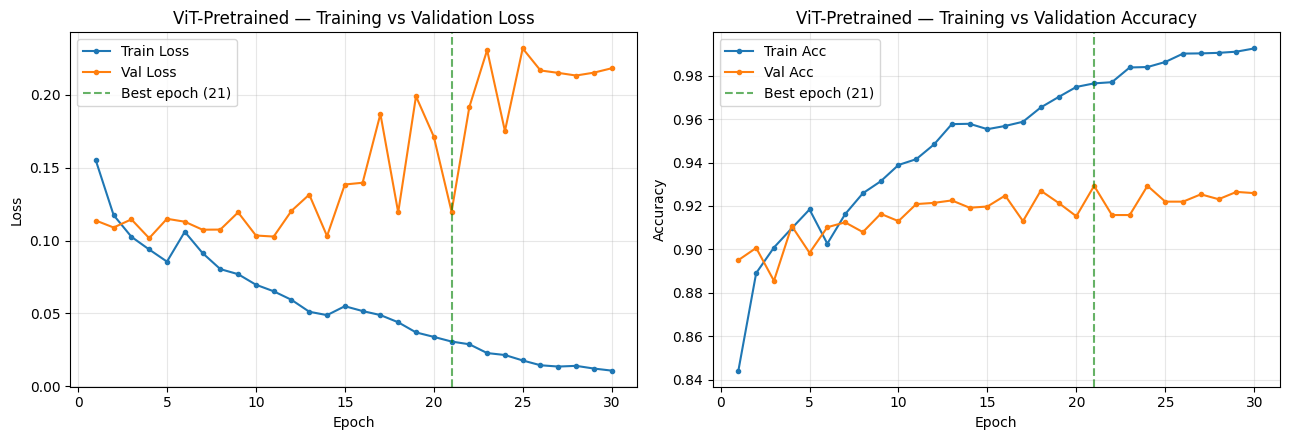

In [10]:

epochs_range = range(1, len(vit_history['train_loss']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_range, vit_history['train_loss'], label='Train Loss', marker='o', ms=3)
axes[0].plot(epochs_range, vit_history['val_loss'],   label='Val Loss',   marker='o', ms=3)
axes[0].axvline(vit_best_ep, color='green', ls='--', alpha=0.6, label=f'Best epoch ({vit_best_ep})')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].set_title('ViT-Pretrained — Training vs Validation Loss')
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, vit_history['train_acc'], label='Train Acc', marker='o', ms=3)
axes[1].plot(epochs_range, vit_history['val_acc'],   label='Val Acc',   marker='o', ms=3)
axes[1].axvline(vit_best_ep, color='green', ls='--', alpha=0.6, label=f'Best epoch ({vit_best_ep})')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].set_title('ViT-Pretrained — Training vs Validation Accuracy')
axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "loss_curve_vit_scratch.png", dpi=150)
plt.show()


## 8. Analisis TPE — Konvergensi & Kepentingan Hyperparameter

Memvisualisasikan proses Bayesian Optimisation untuk ViT-Pretrained dalam tiga panel:

- **Panel A — Kurva Konvergensi TPE**: akurasi tiap trial (titik berwarna) dan trajektori *best-so-far* (garis hijau). Area abu-abu menandai fase startup random (8 trial) sebelum surrogate model TPE aktif. Dengan hanya 15 trial total, fase startup mencakup lebih dari separuh pencarian — ini disengaja agar TPE mendapat sampel awal yang cukup beragam sebelum mulai mengeksploitasi.
- **Panel B — Kepentingan Hyperparameter (fANOVA)**: skor kepentingan mengukur fraksi variansi val-accuracy yang dapat dijelaskan oleh masing-masing hyperparameter. Untuk ViT, `lr` dan `layer_decay` biasanya mendominasi karena keduanya mengontrol seberapa agresif bobot pretrained dimodifikasi.
- **Panel C — Konfigurasi Terbaik**: tabel hyperparameter yang dipilih TPE, diurutkan berdasarkan tingkat kepentingan.


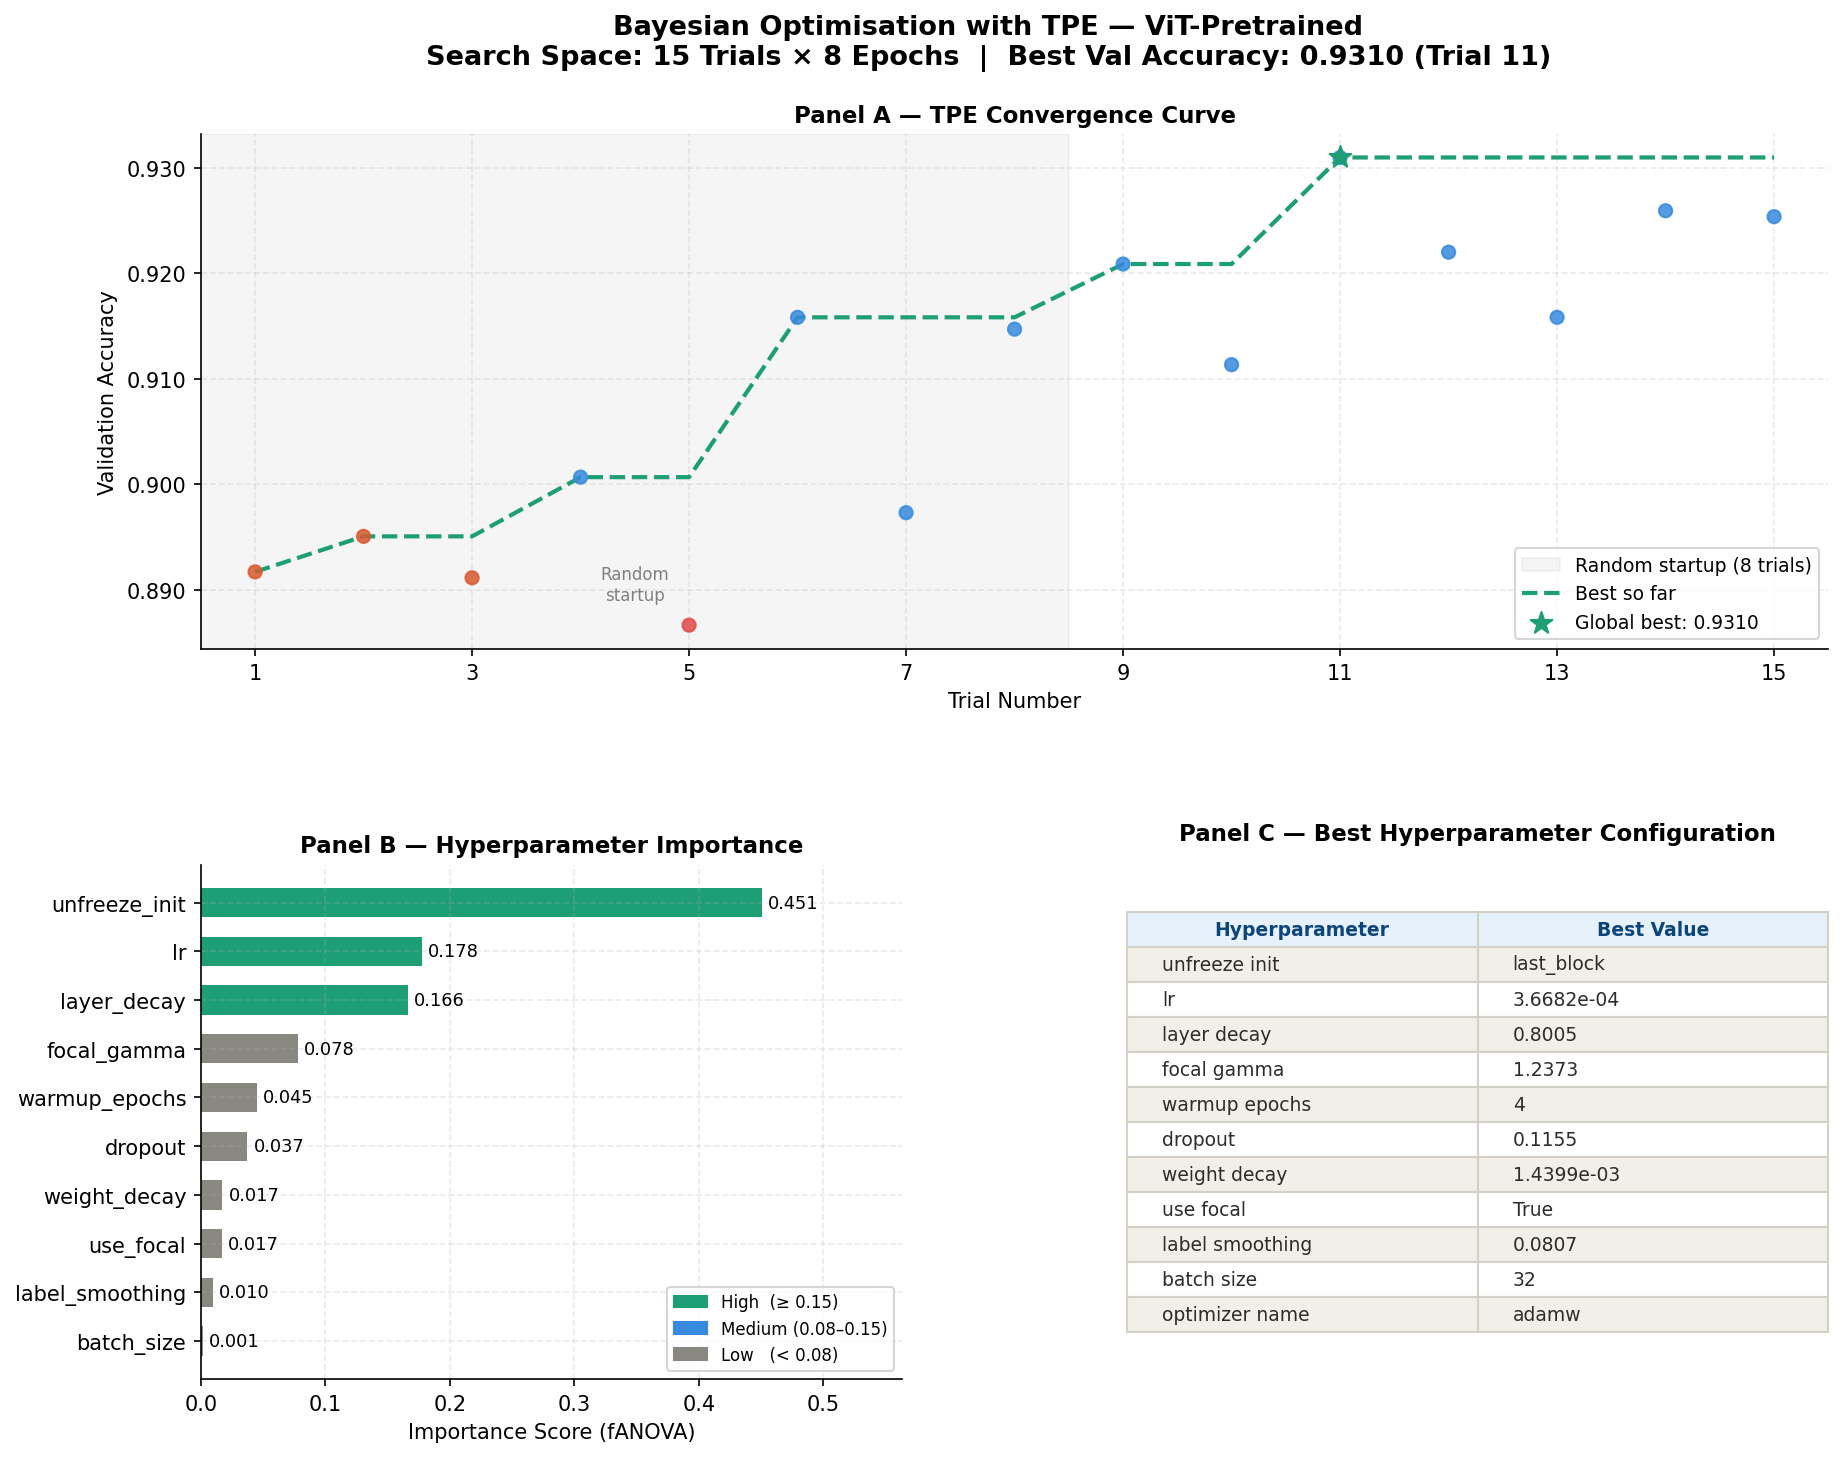

Figure saved: /kaggle/working/full_pipeline_results/tpe_analysis_vit_scratch.png

Hyperparameter Importance (ViT-Pretrained) — fANOVA:
  Hyperparameter         Importance  Rank
  ------------------------------------------
  unfreeze_init              0.4508  #1  ██████████████████████
  lr                         0.1776  #2  ████████
  layer_decay                0.1661  #3  ████████
  focal_gamma                0.0780  #4  ███
  warmup_epochs              0.0449  #5  ██
  dropout                    0.0373  #6  █
  weight_decay               0.0173  #7  
  use_focal                  0.0167  #8  
  label_smoothing            0.0098  #9  
  batch_size                 0.0015  #10  


In [ ]:
matplotlib.rcParams.update({
    'font.family'      : 'DejaVu Sans',
    'axes.spines.top'  : False,
    'axes.spines.right': False,
    'axes.grid'        : True,
    'grid.alpha'       : 0.25,
    'grid.linestyle'   : '--',
    'figure.dpi'       : 150,
})

arch_name_viz = 'vit_scratch'
label_viz     = MODEL_LABELS[arch_name_viz]

trial_values  = [t.value for t in vit_study.trials if t.value is not None]
n_trials      = len(trial_values)
best_so_far   = [max(trial_values[:i+1]) for i in range(n_trials)]
trial_nums    = list(range(1, n_trials + 1))
best_val      = vit_study.best_value
best_trial_n  = vit_study.best_trial.number + 1

importance    = optuna.importance.get_param_importances(
    vit_study,
    evaluator=optuna.importance.FanovaImportanceEvaluator())
hp_names      = list(importance.keys())
hp_scores     = list(importance.values())
sorted_pairs  = sorted(zip(hp_scores, hp_names), reverse=True)
hp_scores_s   = [p[0] for p in sorted_pairs]
hp_names_s    = [p[1] for p in sorted_pairs]

fig = plt.figure(figsize=(14, 10))
fig.suptitle(
    f'Bayesian Optimisation with TPE — {label_viz}\n'
    f'Search Space: {n_trials} Trials × {TPE_EPOCHS} Epochs  |  '
    f'Best Val Accuracy: {best_val:.4f} (Trial {best_trial_n})',
    fontsize=13, fontweight='bold', y=0.98)

gs  = gridspec.GridSpec(2, 2, figure=fig,
                        hspace=0.42, wspace=0.32,
                        top=0.90, bottom=0.07)

C_TRIAL  = '#378ADD'
C_BEST   = '#1D9E75'
C_WORST  = '#E24B4A'
C_START  = (0.533, 0.529, 0.502, 0.07)

ax1 = fig.add_subplot(gs[0, :])

ax1.axvspan(0.5, TPE_WARMUP_TR + 0.5,
            alpha=0.08, color='gray',
            label=f'Random startup ({TPE_WARMUP_TR} trials)')

colors_dot = [C_WORST if v == min(trial_values) else
              ('#D85A30' if v < np.percentile(trial_values, 25) else C_TRIAL)
              for v in trial_values]
ax1.scatter(trial_nums, trial_values,
            c=colors_dot, s=40, zorder=4, alpha=0.85)

ax1.plot(trial_nums, best_so_far,
         color=C_BEST, linewidth=2, linestyle='--',
         label='Best so far', zorder=3)

ax1.scatter([best_trial_n], [best_val],
            color=C_BEST, s=120, zorder=5,
            marker='*', label=f'Global best: {best_val:.4f}')

ax1.text(TPE_WARMUP_TR / 2 + 0.5, min(trial_values) + 0.002,
         'Random\nstartup', fontsize=8, color='gray',
         ha='center', va='bottom')

ax1.set_xlabel('Trial Number', fontsize=10)
ax1.set_ylabel('Validation Accuracy', fontsize=10)
ax1.set_title('Panel A — TPE Convergence Curve', fontsize=11, fontweight='bold')
ax1.set_xlim(0.5, n_trials + 0.5)
ax1.set_xticks(range(1, n_trials + 1, 2))
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
ax1.legend(fontsize=9, loc='lower right')

ax2 = fig.add_subplot(gs[1, 0])

bar_colors = ['#1D9E75' if s >= 0.15 else
              '#378ADD' if s >= 0.08 else
              '#888780' for s in hp_scores_s]

bars = ax2.barh(hp_names_s, hp_scores_s,
                color=bar_colors, height=0.6, edgecolor='none')

for bar, score in zip(bars, hp_scores_s):
    ax2.text(score + 0.005, bar.get_y() + bar.get_height() / 2,
             f'{score:.3f}', va='center', ha='left', fontsize=8.5)

ax2.set_xlabel('Importance Score (fANOVA)', fontsize=10)
ax2.set_title('Panel B — Hyperparameter Importance', fontsize=11, fontweight='bold')
ax2.set_xlim(0, max(hp_scores_s) * 1.25)
ax2.invert_yaxis()

legend_patches = [
    mpatches.Patch(color='#1D9E75', label='High  (≥ 0.15)'),
    mpatches.Patch(color='#378ADD', label='Medium (0.08–0.15)'),
    mpatches.Patch(color='#888780', label='Low   (< 0.08)'),
]
ax2.legend(handles=legend_patches, fontsize=8, loc='lower right')

ax3 = fig.add_subplot(gs[1, 1])
ax3.axis('off')

bp_disp = tpe_best_params['vit_scratch']
rows = []
fmt  = {
    'lr'              : lambda v: f'{v:.4e}',
    'batch_size'      : lambda v: str(int(v)),
    'dropout'         : lambda v: f'{v:.4f}',
    'weight_decay'    : lambda v: f'{v:.4e}',
    'unfreeze_init'   : lambda v: str(v),
    'optimizer_name'  : lambda v: str(v),
    'use_focal'       : lambda v: str(v),
    'focal_gamma'     : lambda v: f'{v:.4f}',
    'label_smoothing' : lambda v: f'{v:.4f}',
    'scheduler_type'  : lambda v: str(v),
    'warmup_epochs'   : lambda v: str(int(v)),
    'layer_decay'     : lambda v: f'{v:.4f}',
}
for k, v in bp_disp.items():
    if k == 'best_val_acc':
        continue
    disp_v = fmt[k](v) if k in fmt else str(v)
    rows.append([k.replace('_', ' '), disp_v])

imp_rank = {k: i for i, k in enumerate(hp_names_s)}
rows.sort(key=lambda r: imp_rank.get(r[0].replace(' ', '_'), 99))

table = ax3.table(
    cellText  = rows,
    colLabels = ['Hyperparameter', 'Best Value'],
    loc='center', cellLoc='left')
table.auto_set_font_size(False)
table.set_fontsize(9)
table.scale(1, 1.4)

for (r, c), cell in table.get_celld().items():
    cell.set_edgecolor('#D3D1C7')
    if r == 0:
        cell.set_facecolor('#E6F1FB')
        cell.set_text_props(fontweight='bold', color='#0C447C')
    else:
        cell.set_facecolor('#FFFFFF' if r % 2 == 0 else '#F1EFE8')
        cell.set_text_props(color='#2C2C2A')

ax3.set_title('Panel C — Best Hyperparameter Configuration',
              fontsize=11, fontweight='bold', pad=12)

out_path = OUTPUT_DIR / f'tpe_analysis_{arch_name_viz}.png'
plt.savefig(out_path, dpi=150, bbox_inches='tight',
            facecolor='white', edgecolor='none')
plt.show()
print(f"Figure saved: {out_path}")

print(f"\nHyperparameter Importance ({label_viz}) — fANOVA:")
print(f"  {'Hyperparameter':<22} {'Importance':>10}  {'Rank'}")
print("  " + "-" * 42)
for rank, (name, score) in enumerate(zip(hp_names_s, hp_scores_s), 1):
    bar = '█' * int(score * 50)
    print(f"  {name:<22} {score:>10.4f}  #{rank}  {bar}")

## 9. Evaluasi Cross-Dataset (DS2)

Menyimpan output DS1 lalu menerapkan model ViT yang telah dilatih ke **DS2 (Mendeley)** tanpa fine-tuning — mengukur kemampuan generalisasi lintas distribusi dataset. Semua probabilitas dan label disimpan sebagai `.npy` untuk digunakan di Scenario II.


In [12]:
import numpy as np

np.save(OUTPUT_DIR / 'probs_ds1_vit_scratch.npy',  vit_probs_te)
np.save(OUTPUT_DIR / 'val_probs_vit_scratch.npy',  vit_vl_probs)
np.save(OUTPUT_DIR / 'val_labels.npy',              vit_vl_labels)
np.save(OUTPUT_DIR / 'ds1_labels.npy',              vit_labels_te)

all_models['vit_scratch']      = vit_model
all_probs_ds1['vit_scratch']   = vit_probs_te
all_metrics_ds1['vit_scratch'] = vit_metrics
all_val_probs['vit_scratch']   = vit_vl_probs


ds2_labels, ds2_probs = get_probs(vit_model, DS2_TEST, VIT_IMG_SIZE, TTA_STEPS)
np.save(OUTPUT_DIR / 'probs_ds2_vit_scratch.npy', ds2_probs)
np.save(OUTPUT_DIR / 'ds2_labels.npy',            ds2_labels)

m  = compute_metrics(ds2_labels, ds2_probs)
d1 = all_metrics_ds1['vit_scratch']

print(f"\nViT-Pretrained — DS1 vs DS2 Generalization:")
print(f"  {'Metric':<12} {'DS1':>8} {'DS2':>8} {'Delta':>10}")
print("  " + "-" * 42)
for k in ['accuracy', 'precision', 'recall', 'f1']:
    diff = m[k] - d1[k]
    print(f"  {k:<12} {d1[k]:>8.4f} {m[k]:>8.4f} {diff:>+10.4f}  {'▼' if diff<0 else '▲'}")

print(f"\nSaved: probs_ds2_vit_scratch.npy")
print(f"Saved: ds2_labels.npy")


ViT-Pretrained — DS1 vs DS2 Generalization:
  Metric            DS1      DS2      Delta
  ------------------------------------------
  accuracy       0.9510   0.9690    +0.0180  ▲
  precision      0.9698   0.9757    +0.0059  ▲
  recall         0.9310   0.9620    +0.0310  ▲
  f1             0.9500   0.9688    +0.0188  ▲

Saved: probs_ds2_vit_scratch.npy
Saved: ds2_labels.npy


## 10. Confusion Matrix DS1 & DS2

Menampilkan confusion matrix berdampingan untuk DS1 dan DS2, memudahkan perbandingan visual pola kesalahan klasifikasi antara kedua dataset.



DS1
  TP: 931  FP: 29
  FN: 69  TN: 971

DS2
  TP: 481  FP: 12
  FN: 19  TN: 488


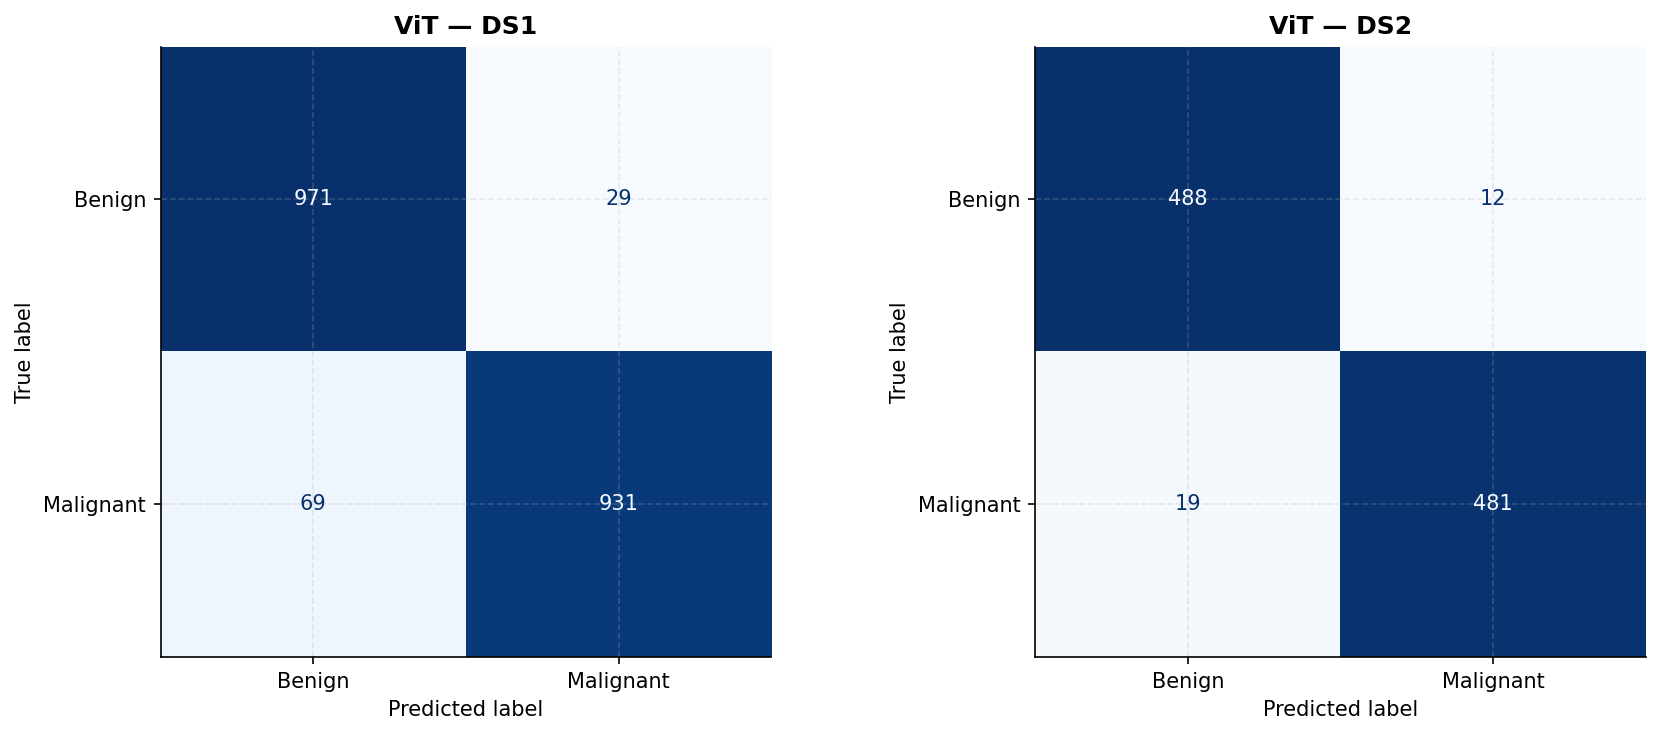

In [14]:
probs_ds1  = vit_probs_te
labels_ds1 = vit_labels_te
probs_ds2  = ds2_probs
labels_ds2 = ds2_labels

preds_ds1 = (probs_ds1 >= 0.5).astype(int)
preds_ds2 = (probs_ds2 >= 0.5).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, (labels, preds, title) in zip(axes, [
    (labels_ds1, preds_ds1, "DS1"),
    (labels_ds2, preds_ds2, "DS2"),
]):
    cm = confusion_matrix(labels, preds)
    ConfusionMatrixDisplay(confusion_matrix=cm,
                           display_labels=["Benign", "Malignant"]).plot(
        ax=ax, cmap="Blues", colorbar=False
    )
    ax.set_title(f"ViT — {title}", fontweight="bold")

    tn, fp, fn, tp = cm.ravel()
    print(f"\n{title}")
    print(f"  TP: {tp}  FP: {fp}")
    print(f"  FN: {fn}  TN: {tn}")

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "confusion_matrix_vit.png", dpi=150)
plt.show()
